### Construct a simple MLP baseline for transfer learning

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from utils import *

In [2]:
class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size_1)  # first layer
        self.fc2 = torch.nn.Linear(hidden_size_1, hidden_size_2)  # first layer
        self.fc3 = torch.nn.Linear(hidden_size_2, hidden_size_3)  # first layer
        self.relu = torch.nn.ReLU()                          # activation
        self.fc4 = torch.nn.Linear(hidden_size_3, output_size) # output layer

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

mlp = MLP(30, 100, 100, 100, 1)


In [3]:
predictor_columns = ['pzabovezmean', 'pzabove2', 'zq5', 'zq10',
    'zq15', 'zq20', 'zq25', 'zq30', 'zq35', 'zq40', 'zq45', 'zq50', 'zq55',
    'zq60', 'zq65', 'zq70', 'zq75', 'zq80', 'zq85', 'zq90', 'zq95',
    'zpcum1', 'zpcum2', 'zpcum3', 'zpcum4', 'zpcum5', 'zpcum6', 'zpcum7',
    'zpcum8', 'zpcum9'
    ]

predictor_columns

#data from Svedala
source_data = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\transfertreeboost\datasets\rs_sweden.csv',
                            index_col=[0])
source_data = source_data[0:1000]

#data from Lettland
target_data = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\transfertreeboost\datasets\rs_lettland.csv',
                            index_col=[0])

def process_dataset_for_base_network(data, batch_size = 32):
    scaler = StandardScaler()
    X = data[predictor_columns].values
    X = scaler.fit_transform(X)
    y = data['Dgv'].values
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).view(-1,1)

    # --- Wrap in TensorDataset ---
    dataset = TensorDataset(X, y)

    # --- Create DataLoader ---
    dataloader_train = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return dataloader_train

dataloader_train = process_dataset_for_base_network(source_data)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11560\1674349650.py:11: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  source_data = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\transfertreeboost\datasets\rs_sweden.csv',


In [4]:
def train_mlp_on_source(dataloader_train, mlp, epochs=100):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4)
    train_loss = []
    for epoch in range(epochs):  # loop over the dataset multiple times
        
        mlp.train()
        running_loss = []
        for i, data in enumerate(dataloader_train):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = mlp(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss.append(np.sqrt(loss.item()))

        running_loss = np.mean(running_loss)  
        train_loss.append(running_loss)  
    return mlp



In [5]:
mlp = train_mlp_on_source(dataloader_train, mlp, epochs=100)

In [6]:
def process_datasets_for_finetuning(data, seed=1, test_size=0.8, val_size=0.5, batch_size=32):
    """
    Splits data into train/val/test, scales X using StandardScaler (fit on train only),
    and returns DataLoaders.
    """
    # --- Split into train/val/test ---
    data_train, data_temp = train_test_split(data, test_size=test_size, random_state=seed)
    data_val, data_test = train_test_split(data_temp, test_size=val_size, random_state=seed)
    
    # --- Scale using train stats only ---
    scaler = StandardScaler()
    X_train = scaler.fit_transform(data_train[predictor_columns].values)
    X_val   = scaler.transform(data_val[predictor_columns].values)
    X_test  = scaler.transform(data_test[predictor_columns].values)

    y_train = data_train['Dgv'].values
    y_val   = data_val['Dgv'].values
    y_test  = data_test['Dgv'].values

    # --- Convert to tensors ---
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val   = torch.tensor(X_val, dtype=torch.float32)
    y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    X_test  = torch.tensor(X_test, dtype=torch.float32)
    y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    # --- Wrap in TensorDataset ---
    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val, y_val)
    test_ds  = TensorDataset(X_test, y_test)

    # --- Create DataLoaders ---
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_dl  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_dl, val_dl, test_dl

dataloader_train, dataloader_val, dataloader_test = process_datasets_for_finetuning(target_data)

In [7]:
def finetune_mlp_on_target(dataloader_train, dataloader_val, mlp, epochs=100, freeze_layers=None):
    # --- Freeze layers if requested ---
    if freeze_layers is not None:
        for name, param in mlp.named_parameters():
            if any(name.startswith(layer) for layer in freeze_layers):
                param.requires_grad = False
                print(f"Freezing {name}")

    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, mlp.parameters()), lr=5e-5)
    
    train_loss = []
    val_loss = []

    for epoch in range(epochs):  # loop over the dataset multiple times
        mlp.train()
        running_loss = []
        for i, data in enumerate(dataloader_train):
            inputs, labels = data
            optimizer.zero_grad()

            outputs = mlp(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss.append(np.sqrt(loss.item()))

        running_loss = np.mean(running_loss)  
        train_loss.append(running_loss)  

        mlp.eval()
        running_loss = []
        for i, data in enumerate(dataloader_val):
            inputs, labels = data
            outputs = mlp(inputs)
            loss = criterion(outputs, labels)
            running_loss.append(np.sqrt(loss.item()))

        running_loss = np.mean(running_loss)  
        val_loss.append(running_loss)  

        if epoch > 0:
            if early_stopping(8, val_loss, tol=1e-6):
                break

    return mlp, train_loss, val_loss


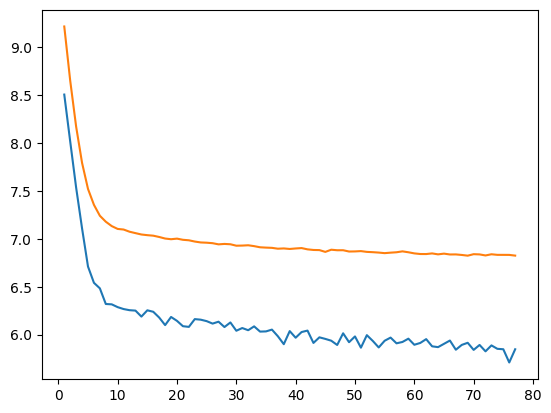

In [ ]:
mlp, train_loss, val_loss = finetune_mlp_on_target(dataloader_train, dataloader_val, mlp, epochs=100)
x = np.linspace(1, len(train_loss), len(train_loss))
plt.plot(x, train_loss)
plt.plot(x, val_loss)
plt.show()

In [ ]:


def test_final_mlp(dataloader_test, mlp, device="cpu"):
    mlp.eval()
    mlp.to(device)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in dataloader_test:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mlp(inputs)

            # Move to CPU + NumPy
            all_preds.append(outputs.numpy())
            all_targets.append(labels.numpy())

    # Concatenate all batches
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    # Compute RMSE on the whole dataset
    rmse = compute_rmse(all_preds, all_targets)
    mae = compute_mae(all_preds, all_targets)
    return mae, rmse


test_final_mlp(dataloader_test, mlp)

np.float32(6.9570985)